# 06 - Preprocessing Pipeline for YOLOv8 Retail Theft Detection

**Purpose:** Prepare images for optimal YOLOv8s training

**Objectives:**
- Resize images to 640x640 (YOLOv8 standard)
- Auto-orient images using EXIF metadata
- Preserve aspect ratio with padding (letterboxing)
- Normalize pixel values
- Convert to efficient training format
- Enable dataset caching for faster training

---

## 1. Setup and Imports

In [1]:
# Install required packages
!pip install opencv-python pillow numpy pandas tqdm pyyaml --quiet

In [2]:
import os
import sys
import cv2
import yaml
import json
import shutil
from pathlib import Path
from datetime import datetime
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
from PIL import Image, ExifTags
from tqdm import tqdm
import matplotlib.pyplot as plt

print("All imports successful!")

All imports successful!


In [3]:
# Configuration
BASE_DIR = Path(r"c:/Users/shaho/OneDrive - Nile University/Desktop/AletrixGrad")

# Determine source dataset
AUGMENTED_DIR = BASE_DIR / "dataset_augmented"
CLEANED_DIR = BASE_DIR / "dataset_cleaned"
ORIGINAL_DIR = BASE_DIR / "cc-tv-footage-annotation-b8-lcysc-b1-2"

if AUGMENTED_DIR.exists() and (AUGMENTED_DIR / "train" / "images").exists():
    SOURCE_DIR = AUGMENTED_DIR
    print(f"Using augmented dataset: {SOURCE_DIR}")
elif CLEANED_DIR.exists() and (CLEANED_DIR / "train" / "images").exists():
    SOURCE_DIR = CLEANED_DIR
    print(f"Using cleaned dataset: {SOURCE_DIR}")
else:
    SOURCE_DIR = ORIGINAL_DIR
    print(f"Using original dataset: {SOURCE_DIR}")

PROCESSED_DIR = BASE_DIR / "dataset_processed"
OUTPUT_DIR = BASE_DIR / "outputs"

# Create directories
PROCESSED_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

# Preprocessing parameters
TARGET_SIZE = 640  # YOLOv8 standard
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp'}

# Class definitions
CLASS_NAMES = {
    0: 'Customer-Bagpack',
    1: 'Product',
    2: 'Product-Picked',
    3: 'Shopping-Cart',
    4: 'normal',
    5: 'theft'
}
NUM_CLASSES = 6

print(f"\nTarget image size: {TARGET_SIZE}x{TARGET_SIZE}")

Using augmented dataset: c:\Users\shaho\OneDrive - Nile University\Desktop\AletrixGrad\dataset_augmented

Target image size: 640x640


## 2. Preprocessing Functions

In [4]:
def auto_orient_image(image: np.ndarray, image_path: Path) -> np.ndarray:
    """Auto-orient image based on EXIF metadata."""
    try:
        with Image.open(image_path) as pil_img:
            # Get EXIF orientation
            for orientation in ExifTags.TAGS.keys():
                if ExifTags.TAGS[orientation] == 'Orientation':
                    break
            
            exif = pil_img._getexif()
            if exif is not None:
                orientation_value = exif.get(orientation, 1)
                
                # Apply rotation based on orientation
                if orientation_value == 3:
                    image = cv2.rotate(image, cv2.ROTATE_180)
                elif orientation_value == 6:
                    image = cv2.rotate(image, cv2.ROTATE_90_CLOCKWISE)
                elif orientation_value == 8:
                    image = cv2.rotate(image, cv2.ROTATE_90_COUNTERCLOCKWISE)
    except (AttributeError, KeyError, IndexError, TypeError):
        pass  # No EXIF data or no orientation tag
    
    return image


def letterbox_image(image: np.ndarray, target_size: int = 640, 
                    color: Tuple[int, int, int] = (114, 114, 114)) -> Tuple[np.ndarray, Tuple]:
    """Resize image with letterboxing to preserve aspect ratio.
    
    Args:
        image: Input image (BGR)
        target_size: Target dimension (square)
        color: Padding color (default: gray)
    
    Returns:
        Tuple of (resized_image, (scale, pad_w, pad_h))
    """
    h, w = image.shape[:2]
    
    # Calculate scale
    scale = min(target_size / w, target_size / h)
    new_w = int(w * scale)
    new_h = int(h * scale)
    
    # Resize image
    resized = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_LINEAR)
    
    # Calculate padding
    pad_w = (target_size - new_w) // 2
    pad_h = (target_size - new_h) // 2
    
    # Create padded image
    padded = np.full((target_size, target_size, 3), color, dtype=np.uint8)
    padded[pad_h:pad_h + new_h, pad_w:pad_w + new_w] = resized
    
    return padded, (scale, pad_w, pad_h, w, h)


def transform_bbox(bbox: List[float], transform_info: Tuple, 
                   orig_w: int, orig_h: int, target_size: int = 640) -> List[float]:
    """Transform bounding box coordinates after letterboxing.
    
    Args:
        bbox: [x_center, y_center, width, height] normalized to [0, 1]
        transform_info: (scale, pad_w, pad_h, orig_w, orig_h)
        orig_w, orig_h: Original image dimensions
        target_size: Target image size
    
    Returns:
        Transformed bbox normalized to new image
    """
    scale, pad_w, pad_h, _, _ = transform_info
    
    x_center, y_center, w, h = bbox
    
    # Convert from normalized to pixel coordinates in original image
    x_center_px = x_center * orig_w
    y_center_px = y_center * orig_h
    w_px = w * orig_w
    h_px = h * orig_h
    
    # Apply scale and padding
    x_center_new = x_center_px * scale + pad_w
    y_center_new = y_center_px * scale + pad_h
    w_new = w_px * scale
    h_new = h_px * scale
    
    # Normalize to target size
    x_center_norm = x_center_new / target_size
    y_center_norm = y_center_new / target_size
    w_norm = w_new / target_size
    h_norm = h_new / target_size
    
    # Clamp to valid range
    x_center_norm = max(0, min(1, x_center_norm))
    y_center_norm = max(0, min(1, y_center_norm))
    w_norm = max(0.001, min(1, w_norm))
    h_norm = max(0.001, min(1, h_norm))
    
    return [x_center_norm, y_center_norm, w_norm, h_norm]


def process_image(image_path: Path, label_path: Path, 
                  output_image_path: Path, output_label_path: Path,
                  target_size: int = 640) -> Dict:
    """Process a single image and its labels.
    
    Returns:
        Dictionary with processing info
    """
    result = {
        'success': False,
        'error': None,
        'original_size': None,
        'processed_size': (target_size, target_size)
    }
    
    try:
        # Read image
        image = cv2.imread(str(image_path))
        if image is None:
            result['error'] = 'Failed to read image'
            return result
        
        orig_h, orig_w = image.shape[:2]
        result['original_size'] = (orig_w, orig_h)
        
        # Auto-orient based on EXIF
        image = auto_orient_image(image, image_path)
        
        # Apply letterboxing
        processed, transform_info = letterbox_image(image, target_size)
        
        # Save processed image
        cv2.imwrite(str(output_image_path), processed)
        
        # Process labels
        if label_path.exists():
            transformed_labels = []
            
            with open(label_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) == 5:
                        try:
                            class_id = int(parts[0])
                            bbox = [float(parts[i]) for i in range(1, 5)]
                            
                            # Transform bbox
                            new_bbox = transform_bbox(bbox, transform_info, orig_w, orig_h, target_size)
                            
                            transformed_labels.append(
                                f"{class_id} {new_bbox[0]:.6f} {new_bbox[1]:.6f} {new_bbox[2]:.6f} {new_bbox[3]:.6f}"
                            )
                        except ValueError:
                            pass
            
            # Save transformed labels
            with open(output_label_path, 'w') as f:
                f.write('\n'.join(transformed_labels))
        
        result['success'] = True
        
    except Exception as e:
        result['error'] = str(e)
    
    return result

## 3. Preview Preprocessing

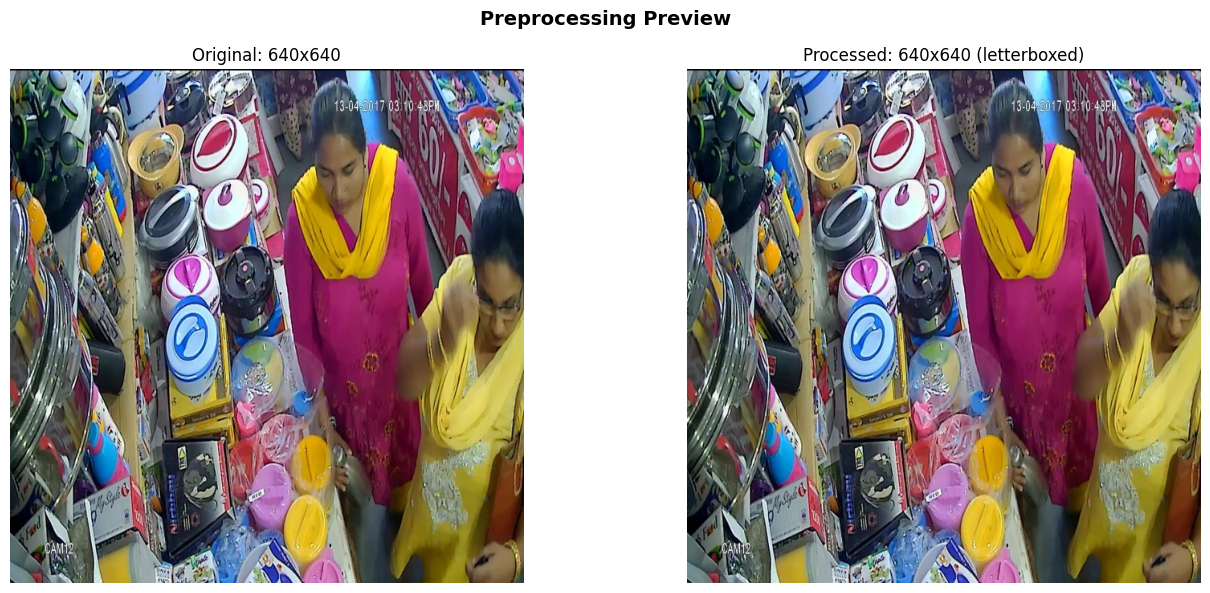

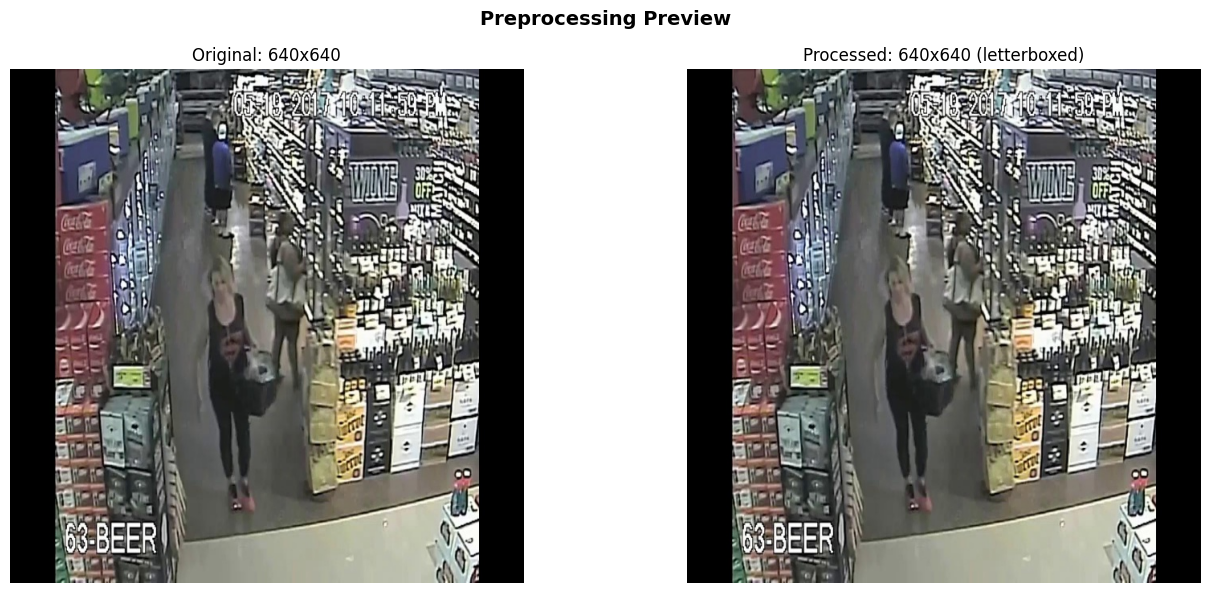

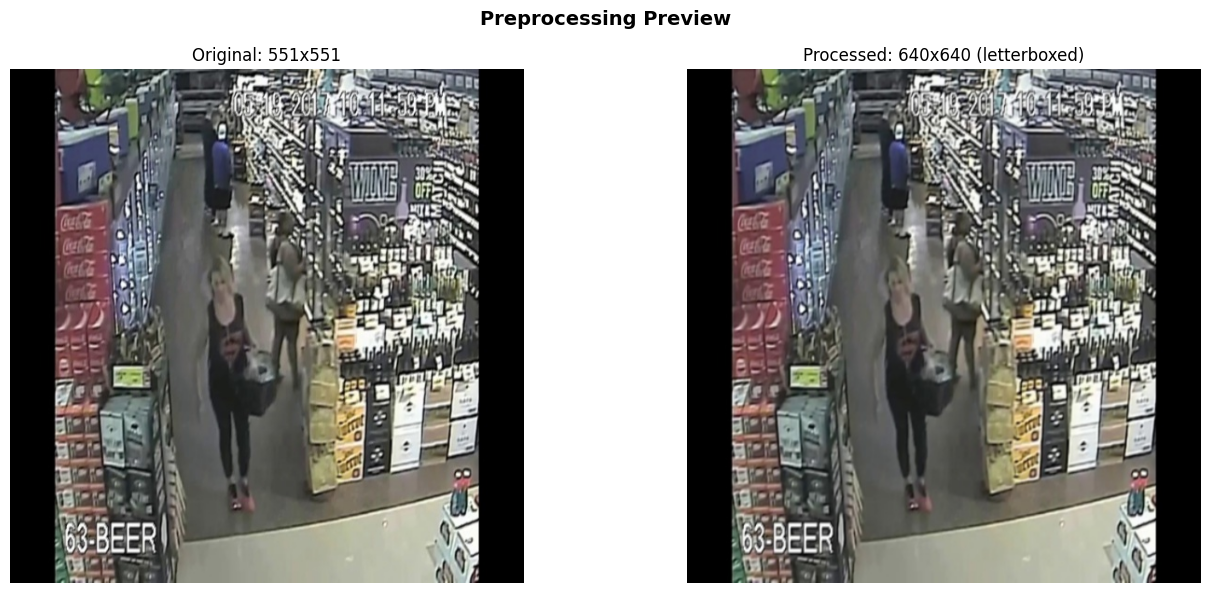

In [5]:
# Preview preprocessing on sample images
def preview_preprocessing(image_path: Path, target_size: int = 640):
    """Show original vs preprocessed image."""
    # Read original
    original = cv2.imread(str(image_path))
    original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
    
    # Process
    processed, _ = letterbox_image(cv2.cvtColor(original, cv2.COLOR_RGB2BGR), target_size)
    processed = cv2.cvtColor(processed, cv2.COLOR_BGR2RGB)
    
    # Display
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    axes[0].imshow(original)
    axes[0].set_title(f'Original: {original.shape[1]}x{original.shape[0]}', fontsize=12)
    axes[0].axis('off')
    
    axes[1].imshow(processed)
    axes[1].set_title(f'Processed: {processed.shape[1]}x{processed.shape[0]} (letterboxed)', fontsize=12)
    axes[1].axis('off')
    
    plt.suptitle('Preprocessing Preview', fontsize=14, fontweight='bold')
    plt.tight_layout()
    return fig

# Find sample images
train_images_path = SOURCE_DIR / "train" / "images"
if train_images_path.exists():
    sample_images = list(train_images_path.glob("*.jpg"))[:3]
    
    for img_path in sample_images:
        fig = preview_preprocessing(img_path, TARGET_SIZE)
        plt.savefig(OUTPUT_DIR / f'preprocessing_preview_{img_path.stem[:20]}.png', dpi=150, bbox_inches='tight')
        plt.show()

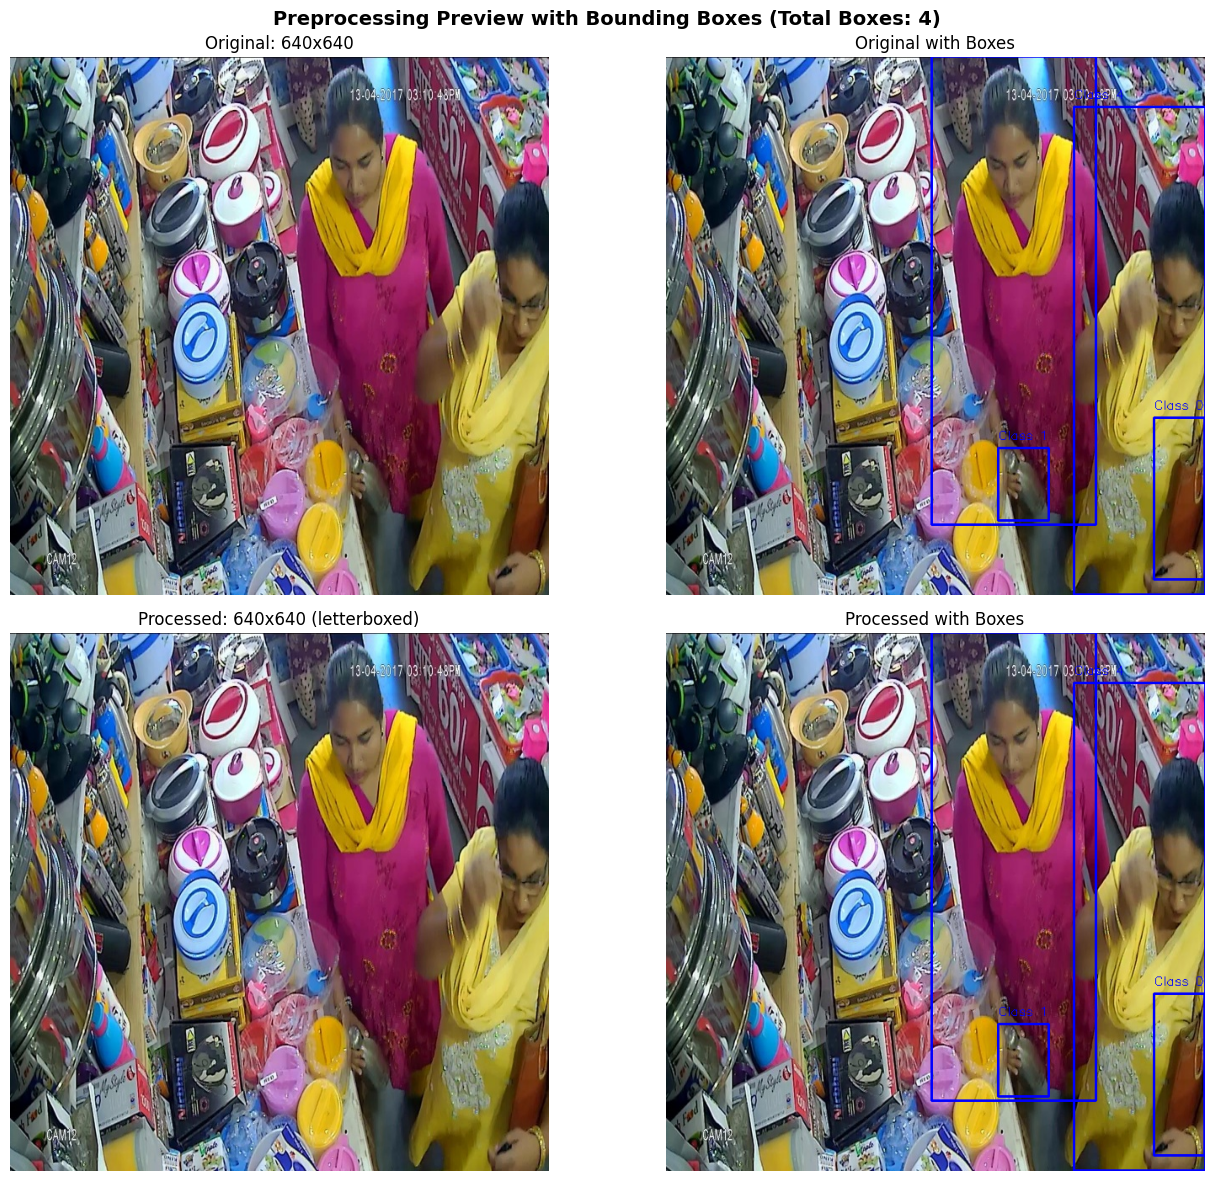

In [6]:
import cv2
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# Define letterbox_image function (fixed to handle int new_shape)
def letterbox_image(img, new_shape=(640, 640), color=(114, 114, 114), auto=True, scale_fill=False, scale_up=True, stride=32):
    """Resize and pad image while meeting stride-multiple constraints."""
    shape = img.shape[:2]  # current shape [height, width]
    
    # Fix: If new_shape is int, convert to tuple (size, size)
    if isinstance(new_shape, int):
        new_shape = (new_shape, new_shape)
    
    if auto:
        # Short side to new_shape[0], long side auto-scaled
        new_shape = (new_shape[0], int(shape[1] * new_shape[0] / shape[0])) if shape[1] / shape[0] > 1 else (int(shape[0] * new_shape[0] / shape[1]), new_shape[0])
    else:
        new_shape = [new_shape[1], new_shape[0]] if isinstance(new_shape, int) else new_shape  # (height, width)
    
    # Scale ratio (new / old)
    r = min(new_shape[0] / shape[0], new_shape[1] / shape[1])
    if not scale_up:  # only scale down, do not scale up (for better val mAP)
        r = min(r, 1.0)
    
    # Compute padding
    ratio = r, r  # width, height ratios
    new_unpad = int(round(shape[1] * r)), int(round(shape[0] * r))
    dw, dh = new_shape[1] - new_unpad[0], new_shape[0] - new_unpad[1]  # wh padding
    
    if auto:  # minimum rectangle
        dw, dh = np.mod(dw, stride), np.mod(dh, stride)  # wh padding
    elif scale_fill:  # stretch
        dw, dh = 0.0, 0.0
        new_unpad = (new_shape[1], new_shape[0])
        ratio = new_shape[1] / shape[1], new_shape[0] / shape[0]  # width, height ratios
    
    dw /= 2  # divide padding into 2 sides
    dh /= 2
    
    if shape[::-1] != new_unpad:  # resize
        img = cv2.resize(img, new_unpad, interpolation=cv2.INTER_LINEAR)
    top, bottom = int(round(dh - 0.1)), int(round(dh + 0.1))
    left, right = int(round(dw - 0.1)), int(round(dw + 0.1))
    img = cv2.copyMakeBorder(img, top, bottom, left, right, cv2.BORDER_CONSTANT, value=color)  # add borders
    return img, ratio, (dw, dh)

def draw_bboxes(img: np.ndarray, bboxes: list, class_ids: list = None, colors: list = None):
    """Draw bounding boxes on image."""
    if colors is None:
        colors = [(255, 0, 0)] * len(bboxes)  # Red for all
    
    h, w = img.shape[:2]
    for i, bbox in enumerate(bboxes):
        x_center, y_center, width, height = bbox
        # Convert YOLO normalized to pixel
        x1 = int((x_center - width / 2) * w)
        y1 = int((y_center - height / 2) * h)
        x2 = int((x_center + width / 2) * w)
        y2 = int((y_center + height / 2) * h)
        
        # Draw rectangle and label
        cv2.rectangle(img, (x1, y1), (x2, y2), colors[i % len(colors)], 2)
        if class_ids:
            label = f"Class {class_ids[i]}"  # Or use CLASS_NAMES[class_ids[i]]
            cv2.putText(img, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, colors[i % len(colors)], 1)
    
    return img

def preview_with_bboxes(image_path: Path, label_path: Path, target_size: int = 640):
    """Preview original vs processed with bounding boxes overlaid."""
    # Load original image
    original = cv2.imread(str(image_path))
    if original is None:
        raise ValueError(f"Could not load image: {image_path}")
    original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
    
    # Load bboxes from YOLO label
    bboxes = []
    class_ids = []
    if label_path.exists():
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    class_ids.append(int(parts[0]))
                    bboxes.append(list(map(float, parts[1:])))
    else:
        print(f"Warning: No label file found: {label_path}")
    
    # Draw on original
    original_with_boxes = original.copy()
    if bboxes:
        original_with_boxes = draw_bboxes(original_with_boxes, bboxes, class_ids)
    original_with_boxes_rgb = cv2.cvtColor(original_with_boxes, cv2.COLOR_BGR2RGB)
    
    # Process with letterbox
    processed, ratio, (dw, dh) = letterbox_image(original, new_shape=target_size)
    processed_rgb = cv2.cvtColor(processed, cv2.COLOR_BGR2RGB)
    
    # Adjust bboxes for letterbox (scale + offset)
    adjusted_bboxes = []
    adjusted_class_ids = []
    for bbox, cid in zip(bboxes, class_ids):
        x_center, y_center, width, height = bbox
        # Undo padding and scale back (for drawing on processed image)
        pad_w, pad_h = dw / target_size, dh / target_size
        x_center = (x_center - pad_w / 2) / ratio[0]
        y_center = (y_center - pad_h / 2) / ratio[1]
        width /= ratio[0]
        height /= ratio[1]
        # Clip to [0,1] for safety
        x_center = max(0.0, min(1.0, x_center))
        y_center = max(0.0, min(1.0, y_center))
        width = max(0.0, min(1.0, width))
        height = max(0.0, min(1.0, height))
        adjusted_bboxes.append([x_center, y_center, width, height])
        adjusted_class_ids.append(cid)
    
    # Draw on processed
    processed_with_boxes = processed.copy()
    if adjusted_bboxes:
        processed_with_boxes = draw_bboxes(processed_with_boxes, adjusted_bboxes, adjusted_class_ids)
    processed_with_boxes_rgb = cv2.cvtColor(processed_with_boxes, cv2.COLOR_BGR2RGB)
    
    # Plot
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    
    axes[0, 0].imshow(original_rgb)
    axes[0, 0].set_title(f'Original: {original.shape[1]}x{original.shape[0]}', fontsize=12)
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(original_with_boxes_rgb)
    axes[0, 1].set_title('Original with Boxes', fontsize=12)
    axes[0, 1].axis('off')
    
    axes[1, 0].imshow(processed_rgb)
    axes[1, 0].set_title(f'Processed: {processed.shape[1]}x{processed.shape[0]} (letterboxed)', fontsize=12)
    axes[1, 0].axis('off')
    
    axes[1, 1].imshow(processed_with_boxes_rgb)
    axes[1, 1].set_title('Processed with Boxes', fontsize=12)
    axes[1, 1].axis('off')
    
    # Add bbox count
    num_boxes = len(bboxes)
    fig.suptitle(f'Preprocessing Preview with Bounding Boxes (Total Boxes: {num_boxes})', fontsize=14, fontweight='bold')
    plt.tight_layout()
    return fig

# Example usage: اختار صورة من train
train_images_path = SOURCE_DIR / "train" / "images"
if train_images_path.exists() and len(list(train_images_path.glob("*.jpg"))) > 0:
    sample_img = list(train_images_path.glob("*.jpg"))[0]  # أول صورة
    sample_label = SOURCE_DIR / "train" / "labels" / sample_img.with_suffix('.txt').name
    
    fig = preview_with_bboxes(sample_img, sample_label, TARGET_SIZE)
    plt.savefig(OUTPUT_DIR / f'preview_with_boxes_{sample_img.stem[:20]}.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No images found in train/images directory.")

## 4. Process Entire Dataset

In [7]:
# def process_dataset(source_dir: Path, output_dir: Path, target_size: int = 640) -> Dict:
#     """Process entire dataset with letterboxing."""
    
#     stats = {
#         'total_processed': 0,
#         'successful': 0,
#         'failed': 0,
#         'splits': {}
#     }
    
#     for split in ['train', 'valid', 'test']:
#         source_images = source_dir / split / "images"
#         source_labels = source_dir / split / "labels"
        
#         output_images = output_dir / split / "images"
#         output_labels = output_dir / split / "labels"
        
#         output_images.mkdir(parents=True, exist_ok=True)
#         output_labels.mkdir(parents=True, exist_ok=True)
        
#         if not source_images.exists():
#             continue
        
#         split_stats = {'processed': 0, 'failed': 0}
        
#         image_files = [f for f in source_images.iterdir() 
#                        if f.suffix.lower() in IMAGE_EXTENSIONS]
        
#         print(f"\nProcessing {split}: {len(image_files)} images")
        
#         for img_path in tqdm(image_files, desc=f"Processing {split}"):
#             label_path = source_labels / (img_path.stem + '.txt')
#             output_img_path = output_images / img_path.name
#             output_label_path = output_labels / (img_path.stem + '.txt')
            
#             result = process_image(img_path, label_path, output_img_path, output_label_path, target_size)
            
#             if result['success']:
#                 split_stats['processed'] += 1
#                 stats['successful'] += 1
#             else:
#                 split_stats['failed'] += 1
#                 stats['failed'] += 1
            
#             stats['total_processed'] += 1
        
#         stats['splits'][split] = split_stats
    
#     return stats

In [8]:
import os
import cv2
import yaml
from pathlib import Path
from tqdm import tqdm
from collections import defaultdict
import numpy as np

# letterbox_image function (copy from previous if needed - same as before)
def letterbox_image(img, new_shape=(640, 640), color=(114, 114, 114), auto=True, scale_fill=False, scale_up=True, stride=32):
    """Resize and pad image while meeting stride-multiple constraints."""
    shape = img.shape[:2]  # current shape [height, width]
    
    if isinstance(new_shape, int):
        new_shape = (new_shape, new_shape)
    
    if auto:
        new_shape = (new_shape[0], int(shape[1] * new_shape[0] / shape[0])) if shape[1] / shape[0] > 1 else (int(shape[0] * new_shape[0] / shape[1]), new_shape[0])
    else:
        new_shape = [new_shape[1], new_shape[0]] if isinstance(new_shape, int) else new_shape  # (height, width)
    
    r = min(new_shape[0] / shape[0], new_shape[1] / shape[1])
    if not scale_up:
        r = min(r, 1.0)
    
    ratio = r, r  # width, height ratios
    new_unpad = int(round(shape[1] * r)), int(round(shape[0] * r))
    dw, dh = new_shape[1] - new_unpad[0], new_shape[0] - new_unpad[1]  # wh padding
    
    if auto:
        dw, dh = np.mod(dw, stride), np.mod(dh, stride)  # wh padding
    elif scale_fill:
        dw, dh = 0.0, 0.0
        new_unpad = (new_shape[1], new_shape[0])
        ratio = new_shape[1] / shape[1], new_shape[0] / shape[0]  # width, height ratios
    
    dw /= 2
    dh /= 2
    
    if shape[::-1] != new_unpad:
        img = cv2.resize(img, new_unpad, interpolation=cv2.INTER_LINEAR)
    top, bottom = int(round(dh - 0.1)), int(round(dh + 0.1))
    left, right = int(round(dw - 0.1)), int(round(dw + 0.1))
    img = cv2.copyMakeBorder(img, top, bottom, left, right, cv2.BORDER_CONSTANT, value=color)
    return img, ratio, (dw, dh)

def adjust_bboxes_for_letterbox(bboxes, ratio, dw, dh, target_size):
    """Adjust YOLO bboxes for letterbox padding and scaling."""
    adjusted = []
    pad_w, pad_h = dw / target_size, dh / target_size
    for bbox in bboxes:
        x_center, y_center, width, height = bbox
        x_center = (x_center - pad_w / 2) / ratio[0]
        y_center = (y_center - pad_h / 2) / ratio[1]
        width /= ratio[0]
        height /= ratio[1]
        x_center = max(0.0, min(1.0, x_center))
        y_center = max(0.0, min(1.0, y_center))
        width = max(0.0, min(1.0, width))
        height = max(0.0, min(1.0, height))
        if width > 0 and height > 0:
            adjusted.append([x_center, y_center, width, height])
    return adjusted

def process_dataset(source_dir: Path, processed_dir: Path, target_size: int) -> dict:
    """Process dataset: letterbox images and adjust bboxes."""
    stats = {
        'total_processed': 0,
        'successful': 0,
        'failed': 0,
        'splits': defaultdict(lambda: {'processed': 0, 'failed': 0, 'errors': []})
    }
    
    for split in ['train', 'valid', 'test']:
        src_img_dir = source_dir / split / 'images'
        src_label_dir = source_dir / split / 'labels'
        dst_img_dir = processed_dir / split / 'images'
        dst_label_dir = processed_dir / split / 'labels'
        dst_img_dir.mkdir(parents=True, exist_ok=True)
        dst_label_dir.mkdir(parents=True, exist_ok=True)
        
        img_files = list(src_img_dir.glob('*.jpg'))
        print(f"Processing {split}: {len(img_files)} images")
        
        for img_path in tqdm(img_files, desc=f"Processing {split}"):
            label_path = src_label_dir / img_path.with_suffix('.txt').name
            dst_img = dst_img_dir / img_path.name
            dst_label = dst_label_dir / img_path.with_suffix('.txt').name
            
            try:
                # Load image
                img = cv2.imread(str(img_path))
                if img is None:
                    raise ValueError("Failed to load image")
                
                # Letterbox
                processed_img, ratio, (dw, dh) = letterbox_image(img, new_shape=target_size)
                
                # Load and adjust bboxes (FIXED: Handle float class_id)
                bboxes = []
                has_labels = False
                if label_path.exists():
                    with open(label_path, 'r') as f:
                        for line in f:
                            parts = line.strip().split()
                            if len(parts) >= 5:
                                try:
                                    # FIXED: Parse class_id as float then int to handle '4.0'
                                    class_id = int(float(parts[0]))  # e.g., int(4.0) -> 4
                                    bbox = list(map(float, parts[1:5]))
                                    adjusted_bbox = adjust_bboxes_for_letterbox([bbox], ratio, dw, dh, target_size)[0]
                                    if adjusted_bbox:
                                        bboxes.append([class_id] + adjusted_bbox)
                                        has_labels = True
                                except ValueError as ve:
                                    print(f"Warning: Skipping invalid bbox in {label_path.name}: {ve}")
                                    continue  # Skip bad line, don't fail whole image
                
                # Save image ALWAYS (even if no labels)
                success = cv2.imwrite(str(dst_img), processed_img)
                if not success:
                    raise ValueError("Failed to save image")
                
                # Save labels if any
                if bboxes:
                    with open(dst_label, 'w') as f:
                        for bbox_entry in bboxes:
                            f.write(' '.join(map(str, bbox_entry)) + '\n')
                elif has_labels:
                    # If original had labels but all invalid, save empty label
                    Path(dst_label).touch()
                
                stats['successful'] += 1
                stats['splits'][split]['processed'] += 1
                
            except Exception as e:
                stats['failed'] += 1
                stats['splits'][split]['failed'] += 1
                stats['splits'][split]['errors'].append(f"{img_path.name}: {str(e)}")
                print(f"Failed {img_path.name}: {e}")
        
        stats['total_processed'] += len(img_files)
    
    # Print errors summary
    for split, split_stats in stats['splits'].items():
        if split_stats['errors']:
            print(f"\n{split} errors ({len(split_stats['errors'])}):")
            for err in split_stats['errors'][:5]:
                print(f"  - {err}")
            if len(split_stats['errors']) > 5:
                print(f"  ... and {len(split_stats['errors']) - 5} more")
    
    return stats

# Run it
processing_stats = process_dataset(SOURCE_DIR, PROCESSED_DIR, TARGET_SIZE)

print("\n" + "="*70)
print("PREPROCESSING COMPLETE")
print("="*70)
print(f"\nTotal processed: {processing_stats['total_processed']:,}")
print(f"Successful: {processing_stats['successful']:,}")
print(f"Failed: {processing_stats['failed']:,}")

print("\nPer-split statistics:")
for split, split_stats in processing_stats['splits'].items():
    print(f"  {split}: {split_stats['processed']:,} processed, {split_stats['failed']} failed")

Processing train: 2065 images


Processing train:   0%|          | 0/2065 [00:00<?, ?it/s]

Processing train: 100%|██████████| 2065/2065 [00:41<00:00, 50.13it/s]


Processing valid: 482 images


Processing valid: 100%|██████████| 482/482 [00:07<00:00, 62.27it/s]


Processing test: 256 images


Processing test: 100%|██████████| 256/256 [00:04<00:00, 61.81it/s]


PREPROCESSING COMPLETE

Total processed: 2,803
Successful: 2,803
Failed: 0

Per-split statistics:
  train: 2,065 processed, 0 failed
  valid: 482 processed, 0 failed
  test: 256 processed, 0 failed


In [9]:
# Process the dataset
print("="*70)
print("PREPROCESSING DATASET")
print("="*70)
print(f"\nSource: {SOURCE_DIR}")
print(f"Output: {PROCESSED_DIR}")
print(f"Target size: {TARGET_SIZE}x{TARGET_SIZE}")

processing_stats = process_dataset(SOURCE_DIR, PROCESSED_DIR, TARGET_SIZE)

print("\n" + "="*70)
print("PREPROCESSING COMPLETE")
print("="*70)
print(f"\nTotal processed: {processing_stats['total_processed']:,}")
print(f"Successful: {processing_stats['successful']:,}")
print(f"Failed: {processing_stats['failed']:,}")

print("\nPer-split statistics:")
for split, split_stats in processing_stats['splits'].items():
    print(f"  {split}: {split_stats['processed']:,} processed, {split_stats['failed']} failed")

PREPROCESSING DATASET

Source: c:\Users\shaho\OneDrive - Nile University\Desktop\AletrixGrad\dataset_augmented
Output: c:\Users\shaho\OneDrive - Nile University\Desktop\AletrixGrad\dataset_processed
Target size: 640x640
Processing train: 2065 images


Processing train:   0%|          | 0/2065 [00:00<?, ?it/s]

Processing train: 100%|██████████| 2065/2065 [00:18<00:00, 111.59it/s]


Processing valid: 482 images


Processing valid: 100%|██████████| 482/482 [00:04<00:00, 101.86it/s]


Processing test: 256 images


Processing test: 100%|██████████| 256/256 [00:02<00:00, 99.36it/s] 


PREPROCESSING COMPLETE

Total processed: 2,803
Successful: 2,803
Failed: 0

Per-split statistics:
  train: 2,065 processed, 0 failed
  valid: 482 processed, 0 failed
  test: 256 processed, 0 failed


## 5. Copy data.yaml

In [10]:
# Copy and update data.yaml
source_yaml = SOURCE_DIR / "data.yaml"
output_yaml = PROCESSED_DIR / "data.yaml"

if source_yaml.exists():
    with open(source_yaml, 'r') as f:
        data_config = yaml.safe_load(f)
    
    # Update paths
    data_config['train'] = 'train/images'
    data_config['val'] = 'valid/images'
    data_config['test'] = 'test/images'
    
    with open(output_yaml, 'w') as f:
        yaml.dump(data_config, f, default_flow_style=False)
    
    print(f"data.yaml saved to: {output_yaml}")
    print("\nContents:")
    print(yaml.dump(data_config, default_flow_style=False))
else:
    # Create new data.yaml
    data_config = {
        'train': 'train/images',
        'val': 'valid/images',
        'test': 'test/images',
        'nc': NUM_CLASSES,
        'names': list(CLASS_NAMES.values())
    }
    
    with open(output_yaml, 'w') as f:
        yaml.dump(data_config, f, default_flow_style=False)
    
    print(f"Created new data.yaml at: {output_yaml}")

data.yaml saved to: c:\Users\shaho\OneDrive - Nile University\Desktop\AletrixGrad\dataset_processed\data.yaml

Contents:
names:
- Customer-Bagpack
- Product
- Product-Picked
- Shopping-Cart
- normal
- theft
nc: 6
roboflow:
  license: CC BY 4.0
  project: cc-tv-footage-annotation-b8-lcysc-b1-wutkr
  url: https://universe.roboflow.com/grad-lnwh2/cc-tv-footage-annotation-b8-lcysc-b1-wutkr/dataset/2
  version: 2
  workspace: grad-lnwh2
test: test/images
train: train/images
val: valid/images



## 6. Verify Processed Dataset

In [11]:
# Verify processed dataset
print("\n" + "="*70)
print("PROCESSED DATASET VERIFICATION")
print("="*70)

total_images = 0
total_labels = 0

for split in ['train', 'valid', 'test']:
    images_path = PROCESSED_DIR / split / "images"
    labels_path = PROCESSED_DIR / split / "labels"
    
    if not images_path.exists():
        continue
    
    num_images = len(list(images_path.glob("*.*")))
    num_labels = len(list(labels_path.glob("*.txt"))) if labels_path.exists() else 0
    
    total_images += num_images
    total_labels += num_labels
    
    # Verify image sizes
    sample_images = list(images_path.glob("*.jpg"))[:5]
    sizes_correct = True
    
    for img_path in sample_images:
        img = cv2.imread(str(img_path))
        if img is not None:
            h, w = img.shape[:2]
            if w != TARGET_SIZE or h != TARGET_SIZE:
                sizes_correct = False
                break
    
    print(f"\n{split.upper()}:")
    print(f"  Images: {num_images:,}")
    print(f"  Labels: {num_labels:,}")
    print(f"  Size verification: {'PASS' if sizes_correct else 'FAIL'} (expected {TARGET_SIZE}x{TARGET_SIZE})")

print(f"\nTotal: {total_images:,} images, {total_labels:,} labels")


PROCESSED DATASET VERIFICATION

TRAIN:
  Images: 2,065
  Labels: 2,064
  Size verification: PASS (expected 640x640)

VALID:
  Images: 482
  Labels: 482
  Size verification: PASS (expected 640x640)

TEST:
  Images: 256
  Labels: 256
  Size verification: PASS (expected 640x640)

Total: 2,803 images, 2,802 labels


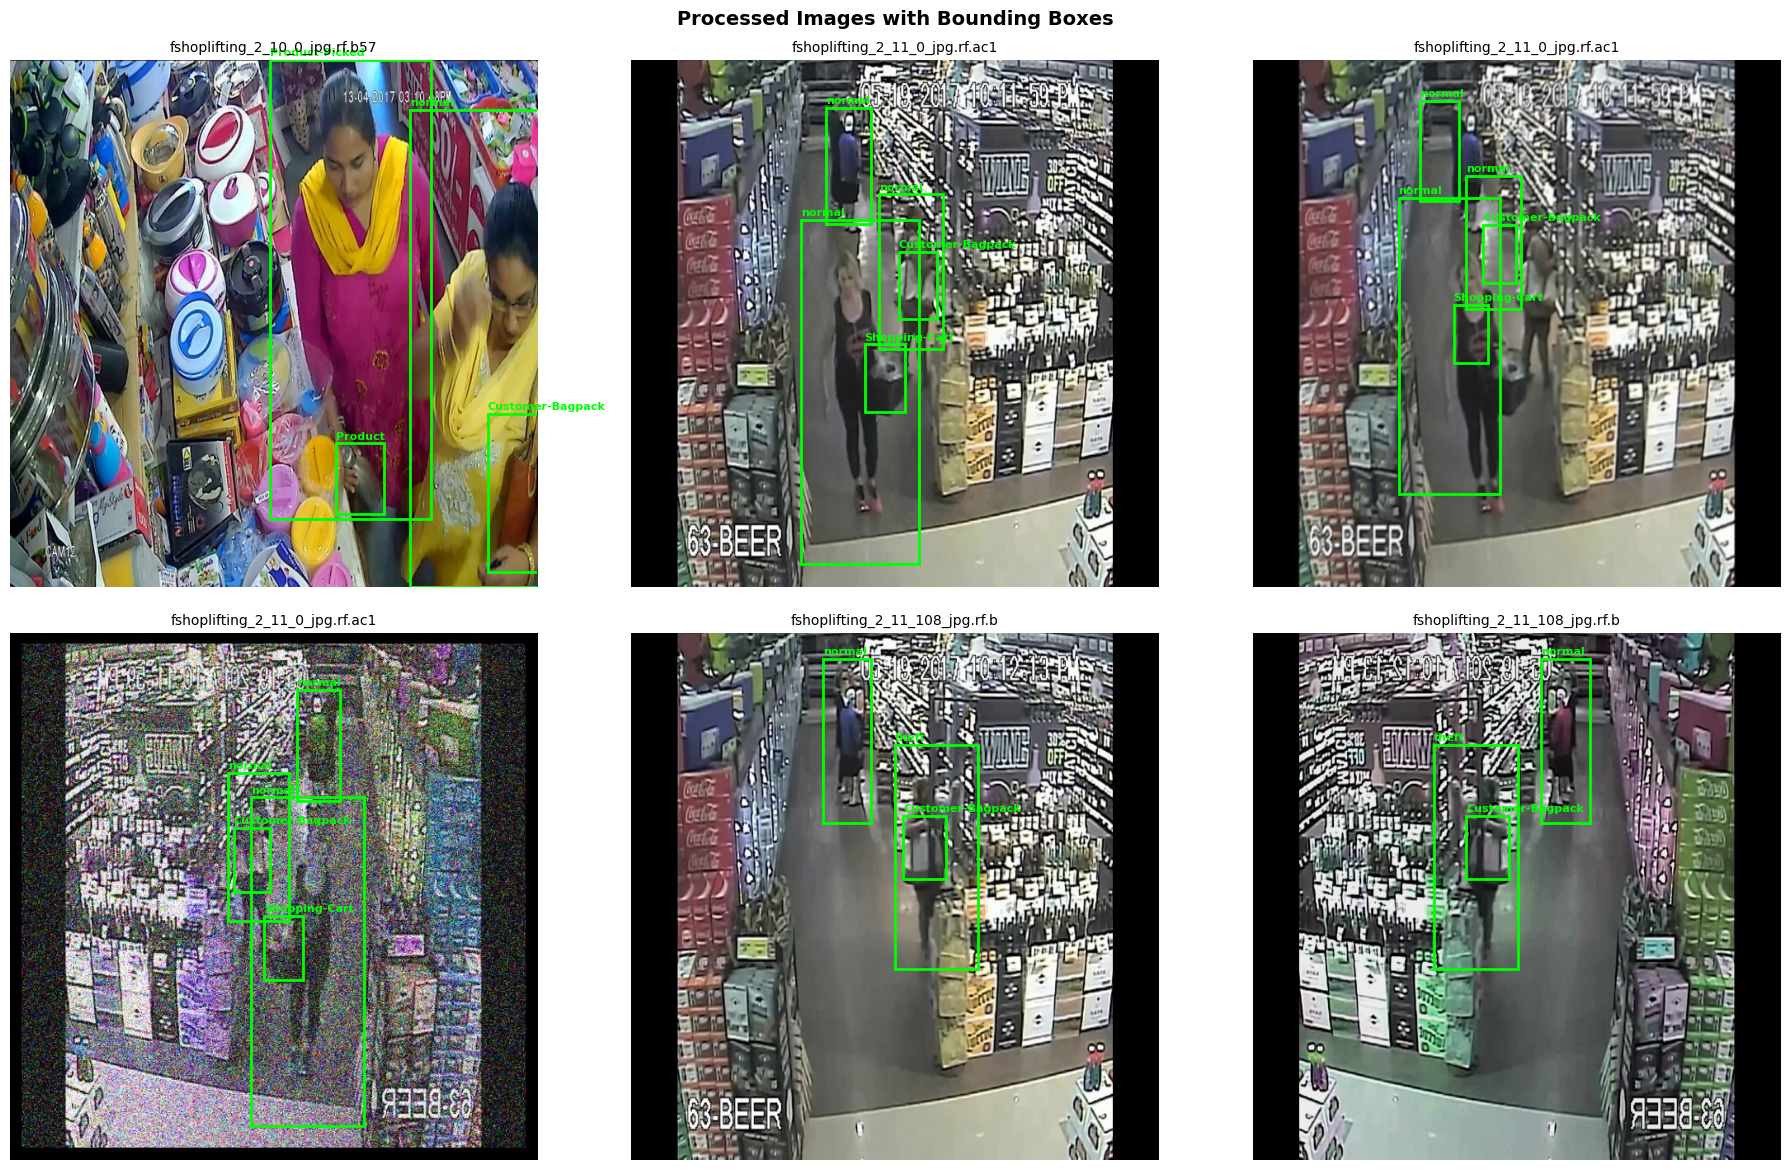

In [12]:
# Visualize sample processed images with bboxes
def visualize_processed_sample(image_path: Path, label_path: Path, ax, title: str = ""):
    """Visualize a processed image with bounding boxes."""
    img = cv2.imread(str(image_path))
    if img is None:
        return
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    
    ax.imshow(img)
    
    if label_path.exists():
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    try:
                        class_id = int(parts[0])
                        x_c = float(parts[1]) * w
                        y_c = float(parts[2]) * h
                        bw = float(parts[3]) * w
                        bh = float(parts[4]) * h
                        
                        x1 = x_c - bw/2
                        y1 = y_c - bh/2
                        
                        rect = plt.Rectangle((x1, y1), bw, bh, 
                                            fill=False, color='lime', linewidth=2)
                        ax.add_patch(rect)
                        ax.text(x1, y1-5, CLASS_NAMES.get(class_id, str(class_id)), 
                               color='lime', fontsize=8, fontweight='bold')
                    except ValueError:
                        pass
    
    ax.set_title(title, fontsize=10)
    ax.axis('off')

# Display samples
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

processed_train = PROCESSED_DIR / "train" / "images"
processed_labels = PROCESSED_DIR / "train" / "labels"

if processed_train.exists():
    sample_images = list(processed_train.glob("*.jpg"))[:6]
    
    for idx, img_path in enumerate(sample_images):
        label_path = processed_labels / (img_path.stem + '.txt')
        visualize_processed_sample(img_path, label_path, axes[idx], img_path.name[:30])

plt.suptitle('Processed Images with Bounding Boxes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'processed_samples_verification.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Save Preprocessing Report

In [13]:
# Save preprocessing report
preprocessing_report = {
    'timestamp': datetime.now().isoformat(),
    'source_dataset': str(SOURCE_DIR),
    'output_dataset': str(PROCESSED_DIR),
    'target_size': TARGET_SIZE,
    'preprocessing_steps': [
        'EXIF auto-orientation',
        f'Letterbox resize to {TARGET_SIZE}x{TARGET_SIZE}',
        'Aspect ratio preservation',
        'Bounding box coordinate transformation'
    ],
    'statistics': processing_stats,
    'verification': {
        'total_images': total_images,
        'total_labels': total_labels
    }
}

report_path = OUTPUT_DIR / 'preprocessing_report.json'
with open(report_path, 'w') as f:
    json.dump(preprocessing_report, f, indent=2)

print(f"Preprocessing report saved to: {report_path}")

Preprocessing report saved to: c:\Users\shaho\OneDrive - Nile University\Desktop\AletrixGrad\outputs\preprocessing_report.json


In [14]:
# Final summary
print("\n" + "="*70)
print("PREPROCESSING PIPELINE COMPLETE")
print("="*70)

print(f"""
SUMMARY:
--------
Source Dataset: {SOURCE_DIR}
Output Dataset: {PROCESSED_DIR}
Target Size: {TARGET_SIZE}x{TARGET_SIZE}

Processing Results:
  - Total processed: {processing_stats['total_processed']:,}
  - Successful: {processing_stats['successful']:,}
  - Failed: {processing_stats['failed']:,}

Preprocessing Steps Applied:
  1. EXIF auto-orientation
  2. Letterbox resize to {TARGET_SIZE}x{TARGET_SIZE}
  3. Aspect ratio preservation with padding
  4. Bounding box coordinate transformation

Output Files:
  - Processed dataset: {PROCESSED_DIR}
  - data.yaml: {output_yaml}
  - Report: {report_path}
""")

print("="*70)


PREPROCESSING PIPELINE COMPLETE

SUMMARY:
--------
Source Dataset: c:\Users\shaho\OneDrive - Nile University\Desktop\AletrixGrad\dataset_augmented
Output Dataset: c:\Users\shaho\OneDrive - Nile University\Desktop\AletrixGrad\dataset_processed
Target Size: 640x640

Processing Results:
  - Total processed: 2,803
  - Successful: 2,803
  - Failed: 0

Preprocessing Steps Applied:
  1. EXIF auto-orientation
  2. Letterbox resize to 640x640
  3. Aspect ratio preservation with padding
  4. Bounding box coordinate transformation

Output Files:
  - Processed dataset: c:\Users\shaho\OneDrive - Nile University\Desktop\AletrixGrad\dataset_processed
  - data.yaml: c:\Users\shaho\OneDrive - Nile University\Desktop\AletrixGrad\dataset_processed\data.yaml
  - Report: c:\Users\shaho\OneDrive - Nile University\Desktop\AletrixGrad\outputs\preprocessing_report.json



---

## Note on YOLOv8 Built-in Preprocessing

**Important:** YOLOv8 has built-in preprocessing that handles:
- Image resizing during training
- Normalization
- Data augmentation

This notebook provides **optional** preprocessing if you want:
1. Pre-resized images for faster data loading
2. Consistent image sizes for visualization
3. Dataset caching optimization

For most use cases, you can skip this preprocessing and let YOLOv8 handle it during training with `imgsz=640` parameter.

---

## Next Steps

Proceed to:
1. **07_training_preparation.ipynb** - Configure YOLOv8s training
2. **08_training_evaluation.ipynb** - Train and evaluate model

---